In [1]:
pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [4]:
df_2025= pd.read_csv(r"C:\Users\NIKITA\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\F6C45318340BE3F8AD07317BE4406F47842C9B90\transfers\2026-11\2025.csv")
df_2026=pd.read_csv(r"C:\Users\NIKITA\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\F6C45318340BE3F8AD07317BE4406F47842C9B90\transfers\2026-11\2026.csv")

In [5]:
df=pd.concat([dataset_2025, dataset_2026])
df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 5984442 entries, 0 to 164959
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   State           str    
 1   District        str    
 2   Market          str    
 3   Commodity       str    
 4   Variety         str    
 5   Grade           str    
 6   Arrival_Date    str    
 7   Min_Price       float64
 8   Max_Price       float64
 9   Modal_Price     float64
 10  Commodity_Code  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 547.9 MB


In [11]:
df.describe()

,Min_Price,Max_Price,Modal_Price,Commodity_Code
count,5.984442e+06,5.984442e+06,5.984442e+06,5.984442e+06
mean,4.018470e+03,4.715419e+03,4.481359e+03,1.041750e+02
std,6.081017e+03,7.022458e+03,6.596095e+03,9.569131e+01
min,0.000000e+00,0.000000e+00,5.000000e-02,1.000000e+00
25%,1.850000e+03,2.200000e+03,2.040000e+03,2.400000e+01
50%,3.000000e+03,3.500000e+03,3.400000e+03,8.200000e+01
75%,5.000000e+03,5.800000e+03,5.500000e+03,1.570000e+02
max,4.000000e+06,4.000000e+06,4.000000e+06,4.800000e+02


In [9]:
df["Max_Price"].describe()

count    5.984442e+06
mean     4.715419e+03
std      7.022458e+03
min      0.000000e+00
25%      2.200000e+03
50%      3.500000e+03
75%      5.800000e+03
max      4.000000e+06
Name: Max_Price, dtype: float64

In [10]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [14]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [11]:
df['Arrival_Date'] 
pd.to_datetime(df['Arrival_Date'], errors='coerce')
data = df.sort_values('Arrival_Date')
print(df['Arrival_Date'].min(), df['Arrival_Date'].max())

01-01-2026 31-12-2025


In [12]:
df['Max_Price'].dtype

dtype('float64')

In [13]:
print(f"Minimum Price: {data['Max_Price'].min()}")
print(f"Maximum Price: {data['Max_Price'].max()}")
print(f"Mean Price: {data['Max_Price'].mean():.2f}") # :.2f rounds to 2 decimal places
print(f"First 20 Unique Values: {data['Max_Price'].unique()[:20]}")

print("\nTop 10 Value Counts:")
print(data['Max_Price'].value_counts().head(10))

Minimum Price: 0.0
Maximum Price: 4000000.0
Mean Price: 4715.42
First 20 Unique Values: [ 20000.   2658.   1910.   5110.   1565.   2651.   5000.   4000.   1900.
   2675.   4461.   3000.   7350.    800.   2500.   5500.   6670.   1620.
   5097. 300000.]

Top 10 Value Counts:
Max_Price
3000.0    376343
4000.0    365385
5000.0    271031
2000.0    263667
6000.0    248671
2500.0    221747
3500.0    192125
7000.0    145538
1500.0    135550
8000.0    119154
Name: count, dtype: int64


In [18]:
top_crops = data['Commodity'].value_counts().head(10)
print("Top 10 crops:\n", top_crops)

Top 10 crops:
 Commodity
Onion                     226844
Tomato                    216087
Potato                    209354
Wheat                     193384
Brinjal                   190408
Banana                    181653
Green Chilli              180539
Bhindi (Ladies Finger)    151879
Bottle gourd              140885
Cabbage                   138396
Name: count, dtype: int64


In [19]:
# Strip spaces and convert to datetime safely
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'].astype(str).str.strip(), errors='coerce')

# Check for invalid dates
invalid_dates = df['Arrival_Date'].isna().sum()
print("Number of invalid dates:", invalid_dates)

Number of invalid dates: 164960


In [20]:
df = df[df['Arrival_Date'].dt.year.isin([2025, 2026])]
print("Shape after filtering:", df.shape)

Shape after filtering: (5819482, 11)


In [21]:
df['Year']=df['Arrival_Date'].dt.year
yearly_avg = df.groupby('Year')['Max_Price'].mean()
print(yearly_avg)

Year
2025    4710.026842
Name: Max_Price, dtype: float64


In [22]:
import matplotlib.pyplot as plt


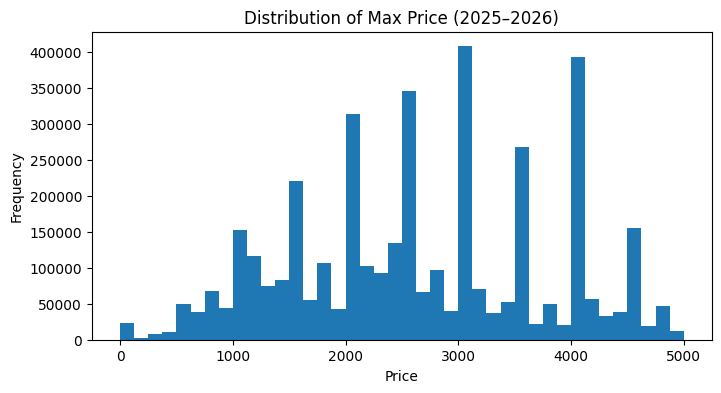

In [ ]:
import matplotlib.pyplot as plt

# 1. Ensure the date column is datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Create a Year-Month column for grouping
# 'MS' stands for Month Start, which keeps the data as actual timestamps
monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['Max_Price'].mean()

# 3. Convert the index back to timestamps for easier plotting
monthly_avg.index = monthly_avg.index.to_timestamp()


plt.figure(figsize=(12, 6))

# Plotting the data
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.title("Monthly Average Max Price (2025-2026)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Max Price", fontsize=12)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



plt.figure(figsize=(8,4))
filtered_data = data[data['Max_Price'] < 5000]
plt.hist(filtered_data['Max_Price'], bins=40)
plt.title("Distribution of Max Price (2025–2026)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

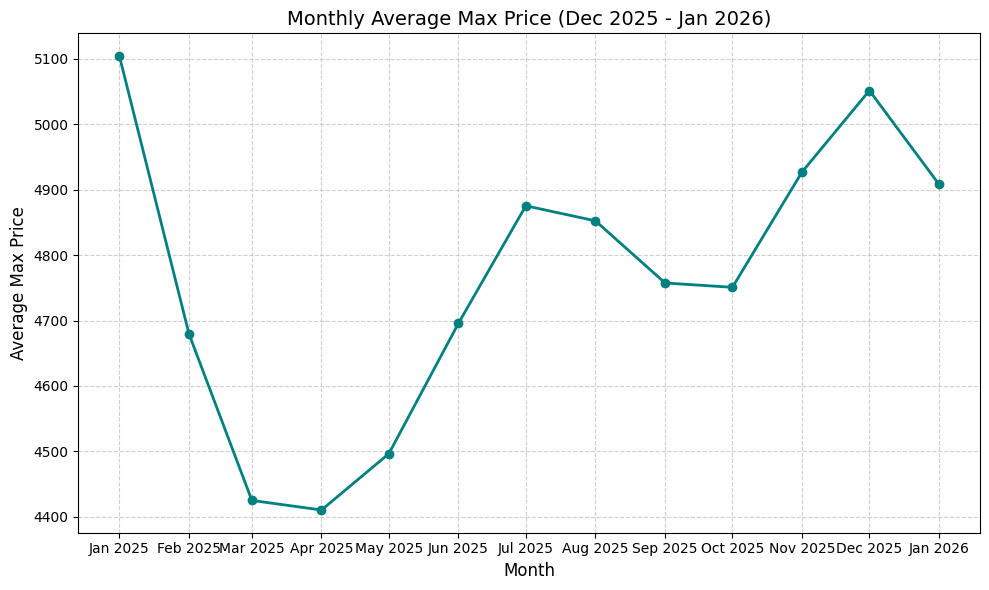

In [8]:
import matplotlib.pyplot as plt

df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])

# 3. Create a Monthly average
# We use .to_period('M') to group by Year-Month specifically
monthly_avg = df.groupby(df['Arrival_Date'].dt.to_period('M'))['Max_Price'].mean()

# Convert the period index back to timestamps for compatible plotting
monthly_avg.index = monthly_avg.index.to_timestamp()

# 4. Plotting the trend
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-', color='teal', linewidth=2)

# Adding labels and title
plt.title("Monthly Average Max Price (Dec 2025 - Jan 2026)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Max Price", fontsize=12)

# Format the X-axis to show month names clearly
plt.xticks(monthly_avg.index, [d.strftime('%b %Y') for d in monthly_avg.index])
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



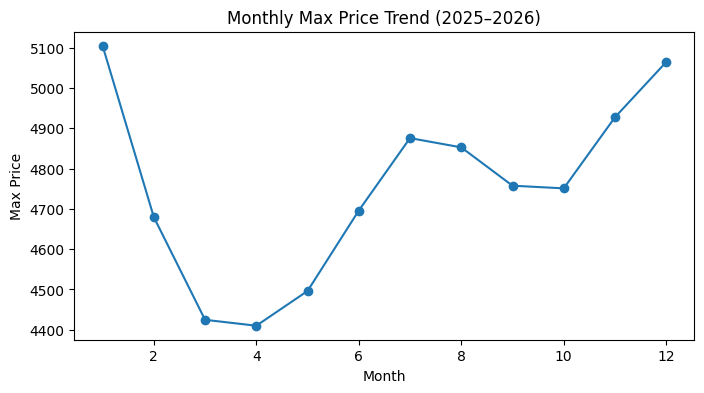

In [25]:
df['month'] = df['Arrival_Date'].dt.month
monthly_avg = df.groupby('month')['Max_Price'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Monthly Max Price Trend (2025–2026)")
plt.xlabel("Month")
plt.ylabel("Max Price")
plt.show()

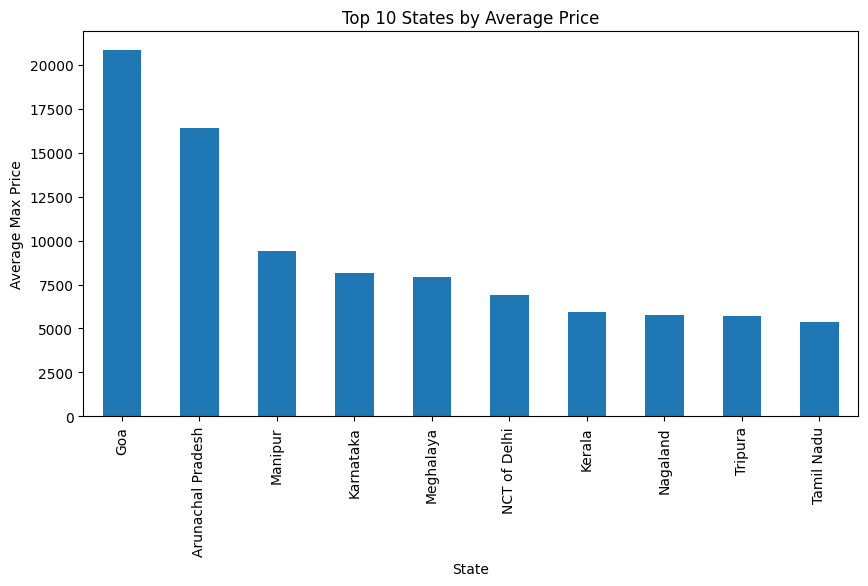

In [26]:
state_avg = df.groupby('State')['Max_Price'].mean().sort_values(ascending=False)
state_avg.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 States by Average Price")
plt.xlabel("State")
plt.ylabel("Average Max Price")
plt.show()

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_2025 = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2025.csv")
df_2026 = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2026.csv")

In [5]:
df = pd.concat([df_2025, df_2026])

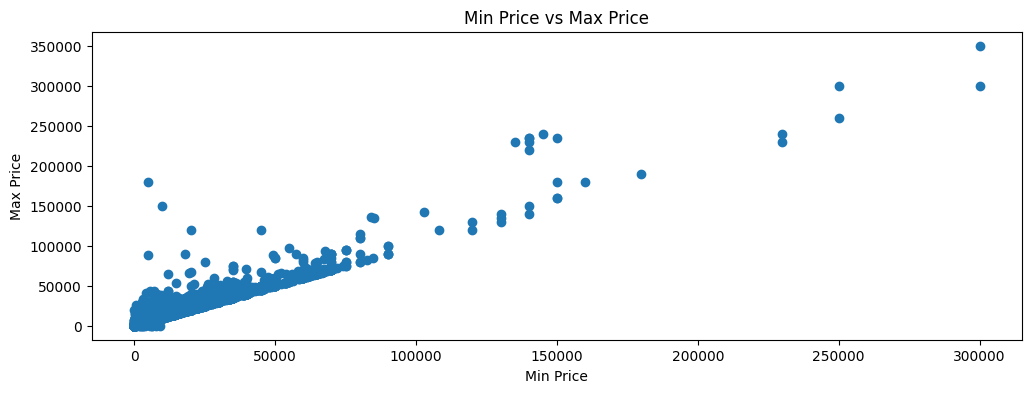

In [28]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.scatter(sample['Min_Price'], sample['Max_Price'])
plt.xlabel("Min Price")
plt.ylabel("Max Price")
plt.title("Min Price vs Max Price")
plt.show()

C:\Users\Anushka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


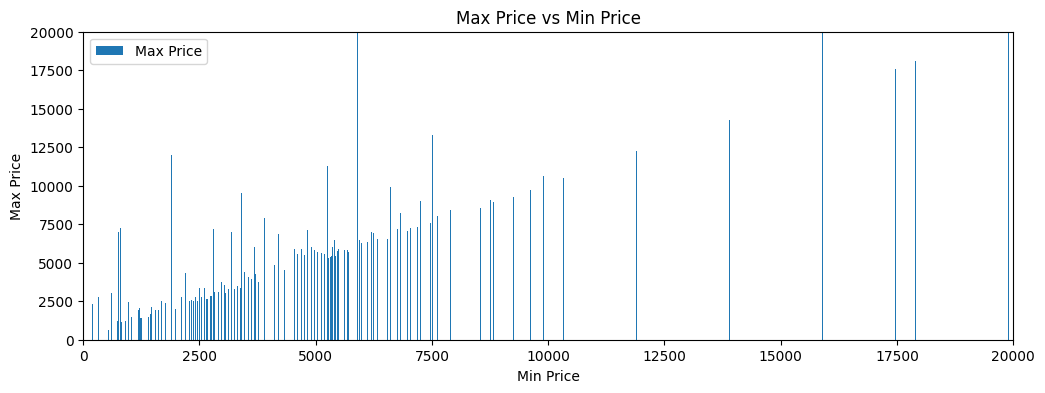

In [29]:
sample = df.sample(100000)

plt.figure(figsize=(12,4))
plt.bar(sample['Min_Price'], sample['Max_Price'], label='Max Price')
plt.xlim(0, 20000)
plt.ylim(0,20000)
plt.xlabel("Min Price")
plt.ylabel("Max Price")
plt.title("Max Price vs Min Price")

plt.legend()
plt.show()

In [30]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
Year              0
month             0
dtype: int64

In [31]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code', 'Year', 'month'],
      dtype='str')

In [5]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Clean the data
df_final = df.dropna(subset=['Max_Price']).copy()

# 2. Use LabelEncoder for all text columns
# We save the encoders in a dictionary so we can use them in Gradio later
encoders = {}
categorical_cols = ['State', 'District', 'Market', 'Commodity', 'Variety']

for col in categorical_cols:
    le = LabelEncoder()
    # Convert to string to avoid errors with mixed types/NaNs
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    encoders[col] = le 

# 3. Define X and y (Using only the columns you want for prediction)
X = df_final[categorical_cols + ['Min_Price', 'Modal_Price']]
y = df_final['Max_Price']

# 4. Fit the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully with Label Encoding!")

Model trained successfully with Label Encoding!


In [20]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Anushka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101
)

In [22]:
from sklearn.linear_model import LinearRegression
df_encoded = pd.get_dummies(sample, columns=['State'])
y = df_encoded['Max_Price']
X = df_encoded.drop('Max_Price', axis=1)

model = LinearRegression()
model.fit(X_train, y_train)

NameError: name 'sample' is not defined

In [23]:
y_pred = model.predict(X_test)
y_pred

array([  651.88190097, 10752.23419141,  7920.09462869, ...,
        6778.86043274,  2948.90834372,  3991.47721231], shape=(1196889,))

In [24]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.975121078883818


In [25]:
print("R2 score: ",r2_score(y_test, y_pred))

R2 score:  0.975121078883818


In [26]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
1199730,800.0,651.881901
5781435,11000.0,10752.234191
4064288,8000.0,7920.094629
5249389,2500.0,2452.299186
2306135,9.0,133.864036


In [4]:
dataset_2025= pd.read_csv(r"C:\Users\Anushka\Desktop\2025.csv")
dataset_2026= pd.read_csv(r"C:\Users\Anushka\Desktop\2026.csv")
df=pd.concat([dataset_2025, dataset_2026])

In [3]:
pip install gradio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Anushka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import gradio as gr
import numpy as np

In [7]:
import gradio as gr
import numpy as np

# 1. The Prediction Logic
def predict_max_price(state, district, market, commodity, variety, min_price, modal_price):
    try:
        # Match the exact column order from your training: Categorical + Min + Modal
        encoded_values = []
        inputs_list = [state, district, market, commodity, variety]
        
        for i, col in enumerate(categorical_cols):
            le = encoders[col]
            # Transform text selection back to the number the model knows
            encoded_values.append(le.transform([str(inputs_list[i])])[0])
        
        # Combine categorical numbers with the two price inputs
        final_features = encoded_values + [min_price, modal_price]
        
        # Predict using the model
        prediction = model.predict([final_features])[0]
        
        # Return formatted HTML for a professional look
        return f"""
        <div style='text-align: center; background: #f0f9ff; padding: 20px; border-radius: 10px; border: 2px solid #bae6fd;'>
            <p style='color: #0369a1; font-size: 16px; margin: 0;'>Estimated Maximum Price</p>
            <h1 style='color: #0284c7; font-size: 36px; margin: 10px 0;'>₹{round(prediction, 2)}</h1>
        </div>
        """
    except Exception as e:
        return f"<p style='color: red;'>Error: {str(e)}</p>"

# 2. The Professional Interface
with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky"), title="MaxPrice AI") as demo:
    gr.Markdown("# 🛰️ MAXIMUM PRICE PREDICTION")
    gr.Markdown("Predict the minimum floor price based on market location and product type.")
    
    with gr.Row():
        # Input Section
        with gr.Column(scale=1, variant="panel"):
            gr.Markdown("### 📍 Location & Product")
            state = gr.Dropdown(choices=list(encoders['State'].classes_), label="State")
            dist = gr.Dropdown(choices=list(encoders['District'].classes_), label="District")
            mkt = gr.Dropdown(choices=list(encoders['Market'].classes_), label="Market")
            comm = gr.Dropdown(choices=list(encoders['Commodity'].classes_), label="Commodity")
            var = gr.Dropdown(choices=list(encoders['Variety'].classes_), label="Variety")
            
            gr.Markdown("### 💰 Known Price Points")
            min_p = gr.Number(label="Min Price (Lower Bound)", value=0)
            mod_p = gr.Number(label="Modal Price (Average)", value=0)
            
            submit_btn = gr.Button("GENERATE PREDICTED MAXIMUM PRICE", variant="primary")

        # Output Section
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Prediction Result")
            output_html = gr.HTML("<p style='text-align: center; color: gray;'>Fill inputs and click generate...</p>")
            
            # Adding a helpful tip box
            gr.Info("Note: This model uses Linear Regression based on historical market trends.")

    # Link button to function
    submit_btn.click(
        fn=predict_max_price,
        inputs=[state, dist, mkt, comm, var, min_p, mod_p],
        outputs=output_html
    )

demo.launch()

C:\Users\Anushka\AppData\Local\Temp\ipykernel_21776\2818596319.py:33: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky"), title="MaxPrice AI") as demo:


Note: This model uses Linear Regression based on historical market trends.
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


C:\Users\Anushka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
